In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/car-resale-dataset-india.csv")

In [5]:
print(df.shape)
print(df.head())
print(df.columns)
print(df.describe())


(140904, 12)
           Brand Model Name Model Variant   Car Type Transmission Fuel Type  \
0       Mahindra     TUV300           AX5        SUV       Manual       CNG   
1          Skoda      Rapid         Style      Sedan       Manual    Petrol   
2  Maruti Suzuki       Alto             Z  Hatchback       Manual    Diesel   
3        Hyundai  Grand i10         Magna  Hatchback       Manual    Diesel   
4       Mahindra     XUV500            W8        SUV       Manual    Petrol   

   Year  Kilometers Owner           State Accidental   Price  
0  2017      164654   1st       Rajasthan         No  547253  
1  2018       41351   1st     Maharashtra         No  512050  
2  2002      119090  3rd+      Tamil Nadu         No  678923  
3  2013       19979   1st  Andhra Pradesh         No  522500  
4  2011      130591  3rd+           Bihar         No  401182  
Index(['Brand', 'Model Name', 'Model Variant', 'Car Type', 'Transmission',
       'Fuel Type', 'Year', 'Kilometers', 'Owner', 'State',

In [6]:
print(df.isna().sum())
print(df.info())

Brand            0
Model Name       0
Model Variant    0
Car Type         0
Transmission     0
Fuel Type        0
Year             0
Kilometers       0
Owner            0
State            0
Accidental       0
Price            0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 140904 entries, 0 to 140903
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Brand          140904 non-null  str  
 1   Model Name     140904 non-null  str  
 2   Model Variant  140904 non-null  str  
 3   Car Type       140904 non-null  str  
 4   Transmission   140904 non-null  str  
 5   Fuel Type      140904 non-null  str  
 6   Year           140904 non-null  int64
 7   Kilometers     140904 non-null  int64
 8   Owner          140904 non-null  str  
 9   State          140904 non-null  str  
 10  Accidental     140904 non-null  str  
 11  Price          140904 non-null  int64
dtypes: int64(3), str(9)
memory usage: 19.5 MB
None


In [7]:
print(df.nunique())

Brand               18
Model Name          84
Model Variant       82
Car Type             5
Transmission         2
Fuel Type            5
Year                24
Kilometers       95860
Owner                3
State               27
Accidental           2
Price            17745
dtype: int64


In [10]:
categorial_cols=df.select_dtypes(include="str").columns

for col in categorial_cols:
    print(f"{col}:")
    print(df[col].value_counts())


Brand:
Brand
Maruti Suzuki    54030
Hyundai          22090
Honda            11936
Toyota           10483
Mahindra          9618
Tata              8825
Ford              5217
Volkswagen        3716
Renault           3024
Nissan            2184
Kia               2146
Skoda             1537
MG                1492
BMW               1052
Audi              1012
Range Rover        906
Jaguar             884
Chevrolet          752
Name: count, dtype: int64
Model Name:
Model Name
Dzire     6157
Ertiga    6037
WagonR    6022
Swift     6004
Baleno    6003
          ... 
Cruze      165
Tavera     154
Spark      153
Sail       141
Beat       139
Name: count, Length: 84, dtype: int64
Model Variant:
Model Variant
V            14975
ZX           14896
Base         14199
L            10824
Z            10692
             ...  
R-Dynamic      221
Portfolio      217
LTZ            196
LS             190
LT             169
Name: count, Length: 82, dtype: int64
Car Type:
Car Type
Hatchback    55890
Sedan  

In [11]:
df[["Year", "Kilometers", "Price"]].describe()

,Year,Kilometers,Price
count,140904.000000,140904.000000,1.409040e+05
mean,2016.960391,95024.595987,7.617872e+05
std,5.106106,49133.157878,4.438578e+05
min,2000.000000,10000.000000,5.005500e+04
25%,2014.000000,52421.000000,4.116420e+05
50%,2018.000000,94973.500000,6.828030e+05
75%,2021.000000,137618.000000,1.034178e+06
max,2023.000000,179998.000000,2.744280e+06


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
print("Invalid years:", ((df["Year"] < 2000) | (df["Year"] > 2023)).sum())

print("Invalid kilometers:", (df["Kilometers"] <= 0).sum())

print("Invalid prices:", (df["Price"] <= 0).sum())

Invalid years: 0
Invalid kilometers: 0
Invalid prices: 0


In [14]:
df["Price"].describe()

count    1.409040e+05
mean     7.617872e+05
std      4.438578e+05
min      5.005500e+04
25%      4.116420e+05
50%      6.828030e+05
75%      1.034178e+06
max      2.744280e+06
Name: Price, dtype: float64

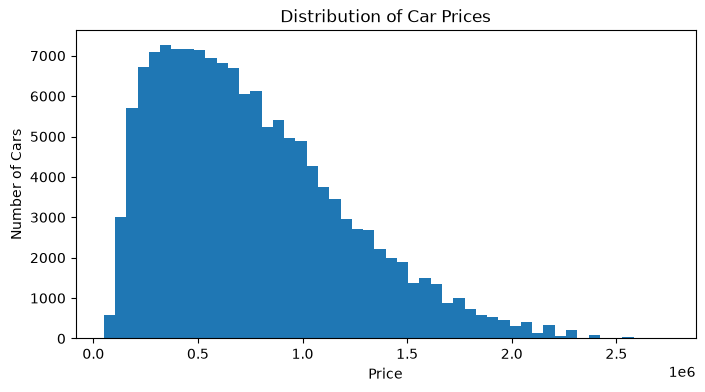

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df["Price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Prices")
plt.show()